# 모델 성능 비교: LSTM, GRU, Transformer, 1D-CNN+Transformer

WESAD 데이터셋에서 4가지 모델의 Loss와 Accuracy를 비교합니다.

Using device: cuda:0
DATASET_PATH: /home/binghin2/Myproject/Dataset/WESAD


/tmp/ipykernel_2009/2602826766.py:447: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


Processed TEST user: S15, n_features=9, windows=36
Processed TEST user: S16, n_features=9, windows=36
Processed TEST user: S17, n_features=9, windows=36

Model file: cnn_transformer_more_epochs_model.pt
- expected n_features: 9
- test shape: (108, 240, 9), label dist: [57 33 18]


/tmp/ipykernel_2009/2602826766.py:447: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


Processed TEST user: S15, n_features=10, windows=36
Processed TEST user: S16, n_features=10, windows=36
Processed TEST user: S17, n_features=10, windows=36

Model file: gru_model.pt
- expected n_features: 10
- test shape: (108, 240, 10), label dist: [57 33 18]

Model file: lstm_model.pt
- expected n_features: 10
- test shape: (108, 240, 10), label dist: [57 33 18]

Model file: transformer_model.pt
- expected n_features: 10
- test shape: (108, 240, 10), label dist: [57 33 18]


/tmp/ipykernel_2009/2602826766.py:447: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)
/tmp/ipykernel_2009/2602826766.py:447

,Model,Checkpoint,n_features,Test Loss,Test Accuracy (%),Macro F1,Weighted F1
0,1D-CNN+Transformer,cnn_transformer_more_epochs_model.pt,9,1.194939,59.259259,0.430340,0.558923
1,Transformer,transformer_model.pt,10,1.329187,30.555556,0.298712,0.310047
2,GRU,gru_model.pt,10,1.601677,22.222222,0.183697,0.188289
3,LSTM,lstm_model.pt,10,1.724886,29.629630,0.171112,0.171424



모델 체크포인트 기반 성능 비교 (모델별 n_features 자동 매칭)
             Model                           Checkpoint  n_features  Test Loss  Test Accuracy (%)  Macro F1  Weighted F1
1D-CNN+Transformer cnn_transformer_more_epochs_model.pt           9   1.194939          59.259259  0.430340     0.558923
       Transformer                 transformer_model.pt          10   1.329187          30.555556  0.298712     0.310047
               GRU                         gru_model.pt          10   1.601677          22.222222  0.183697     0.188289
              LSTM                        lstm_model.pt          10   1.724886          29.629630  0.171112     0.171424


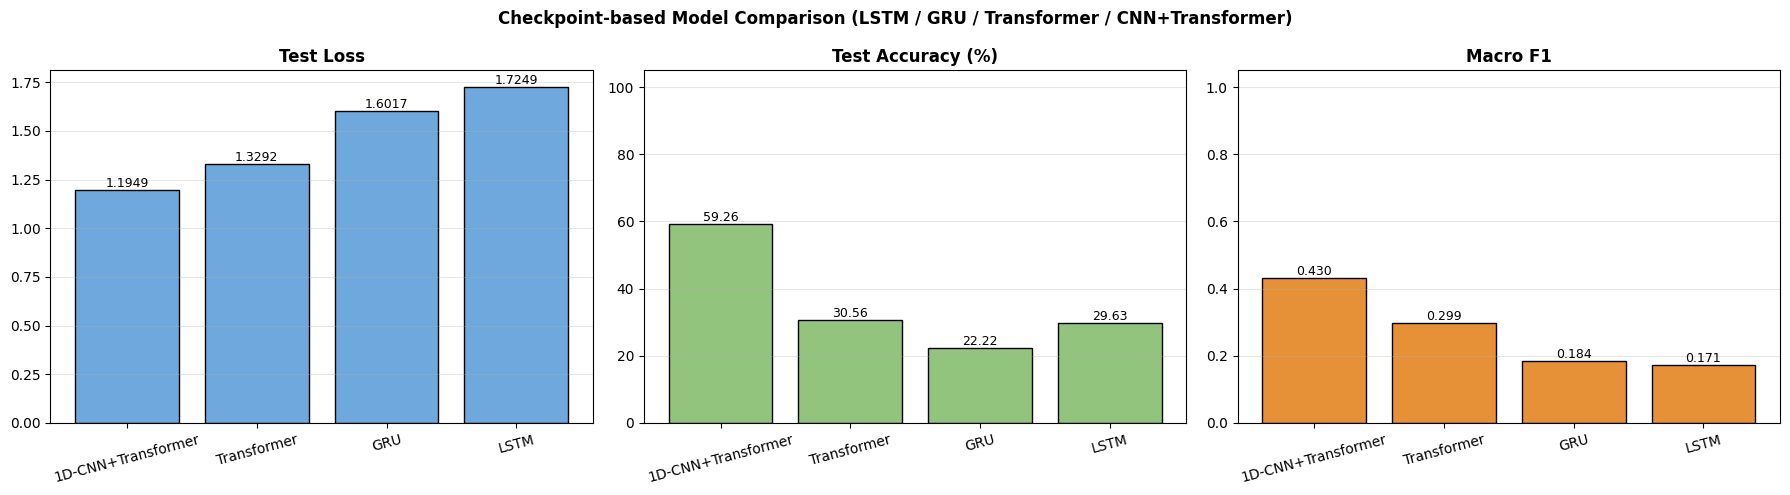

In [18]:
# 실제 저장된 모델(.pt) 로드 기반 성능 비교 (Loss / Accuracy / F1)
import os
import pickle
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# -----------------------------
# 1) 경로 / 설정
# -----------------------------
MODEL_PATHS = [
    '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_more_epochs_model.pt',
    '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/GRU/gru_model.pt',
    '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/LSTM/lstm_model.pt',
    '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/Transformer/transformer_model.pt',
]

DATASET_CANDIDATES = [
    '/home/binghin2/Myproject/Research/Dataset/WESAD',
    '/home/binghin2/Myproject/Dataset/WESAD',
    '../../../Dataset/WESAD',
    '../../Dataset/WESAD',
]

DATASET_PATH = None
for cand in DATASET_CANDIDATES:
    if os.path.exists(cand):
        DATASET_PATH = cand
        break

if DATASET_PATH is None:
    raise FileNotFoundError(
        'WESAD 데이터셋 경로를 찾지 못했습니다. DATASET_CANDIDATES를 현재 환경에 맞게 수정하세요.'
    )

TEST_USERS = ['S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2}
DOWNSAMPLE_RATE = 4
WINDOW_SIZE_SEC = 60
TEST_STRIDE_SEC = 60
LABEL_PURITY_THRESHOLD = 0.8
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'DATASET_PATH: {DATASET_PATH}')

# -----------------------------
# 2) 전처리 함수 (모델별 n_features 대응)
# -----------------------------
def _to_2d_column(signal):
    signal = np.asarray(signal)
    if signal.ndim == 1:
        return signal.reshape(-1, 1)
    return signal

def _resample_signal(signal, orig_rate, target_rate):
    signal_2d = _to_2d_column(signal)
    if orig_rate == target_rate:
        return signal_2d
    return resample_poly(signal_2d, up=target_rate, down=orig_rate, axis=0)

def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    normalized_cutoff = cutoff_hz / nyq
    b, a = butter(order, normalized_cutoff, btype='low')

    if len(eda_flat) <= (max(len(a), len(b)) * 3):
        scl = np.copy(eda_flat)
    else:
        scl = filtfilt(b, a, eda_flat)

    scr = eda_flat - scl
    return scl.reshape(-1, 1), scr.reshape(-1, 1)

def extract_bvp_features(bvp, orig_rate=64, target_rate=4):
    bvp_flat = np.asarray(bvp).flatten()
    min_distance = int(orig_rate * 0.3)
    peaks, _ = find_peaks(bvp_flat, distance=min_distance)

    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)

    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]

        hr_continuous = np.interp(times_target, peak_times, hr)
        ibi_continuous = np.interp(times_target, peak_times, ibi)

        ibi_series = pd.Series(ibi_continuous)
        hrv_continuous = (
            ibi_series
            .rolling(window=target_rate * 10, min_periods=1)
            .std()
            .fillna(0.0)
            .values
        )
    else:
        hr_continuous = np.zeros(target_len)
        ibi_continuous = np.zeros(target_len)
        hrv_continuous = np.zeros(target_len)

    return np.concatenate([
        hr_continuous.reshape(-1, 1),
        ibi_continuous.reshape(-1, 1),
        hrv_continuous.reshape(-1, 1),
    ], axis=1)

def load_subject_components(subject_path):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    acc = wrist['ACC']      # 32Hz
    bvp = wrist['BVP']      # 64Hz
    eda = wrist['EDA']      # 4Hz
    temp = wrist['TEMP']    # 4Hz
    labels = data['label']  # 700Hz

    bvp_features = extract_bvp_features(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    scl_eda, scr_eda = decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2)

    acc_down = _resample_signal(acc, orig_rate=32, target_rate=DOWNSAMPLE_RATE)
    bvp_down = _resample_signal(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    eda_down = _resample_signal(eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    scl_down = _resample_signal(scl_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    scr_down = _resample_signal(scr_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    temp_down = _resample_signal(temp, orig_rate=4, target_rate=DOWNSAMPLE_RATE)

    label_timestamps = np.arange(len(labels)) / 700.0
    data_timestamps = np.arange(len(acc_down)) / float(DOWNSAMPLE_RATE)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)

    min_len = min(
        len(acc_down), len(bvp_down), len(eda_down), len(scl_down), len(scr_down),
        len(temp_down), len(bvp_features), len(labels_down)
    )

    return {
        'acc': acc_down[:min_len],
        'bvp': bvp_down[:min_len],
        'eda': eda_down[:min_len],
        'scl': scl_down[:min_len],
        'scr': scr_down[:min_len],
        'temp': temp_down[:min_len],
        'bvp_feat': bvp_features[:min_len],
        'labels': labels_down[:min_len],
    }

def build_feature_matrix(comp, n_features):
    # 10 features (new): ACC3 + BVP + SCL + SCR + TEMP + HR + IBI + HRV
    feat10 = np.concatenate([
        comp['acc'], comp['bvp'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']
    ], axis=1)

    # 9 features (legacy candidate): ACC3 + SCL + SCR + TEMP + HR + IBI + HRV
    feat9 = np.concatenate([
        comp['acc'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']
    ], axis=1)

    # 6 features (legacy): ACC3 + BVP + EDA + TEMP
    feat6 = np.concatenate([
        comp['acc'], comp['bvp'], comp['eda'], comp['temp']
    ], axis=1)

    if n_features == 10:
        return feat10
    if n_features == 9:
        return feat9
    if n_features == 6:
        return feat6

    if n_features < 10:
        print(f'[WARN] n_features={n_features} 비표준. feat10의 앞 {n_features}개 컬럼을 사용합니다.')
        return feat10[:, :n_features]

    raise ValueError(f'n_features={n_features}가 지원 범위를 벗어났습니다.')

def create_windows(features, labels, stride_sec):
    window_samples = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    stride_samples = max(1, int(stride_sec * DOWNSAMPLE_RATE))

    X, y = [], []
    i = 0
    max_start = len(features) - window_samples

    while i <= max_start:
        w_feat = features[i : i + window_samples]
        w_lab = labels[i : i + window_samples].astype(int)

        counts = np.bincount(w_lab)
        if counts.size > 0:
            mf = int(counts.argmax())
            purity = counts[mf] / float(window_samples)
            if mf in TARGET_LABELS and purity >= LABEL_PURITY_THRESHOLD:
                X.append(w_feat)
                y.append(TARGET_LABELS[mf])

        i += stride_samples

    return np.array(X), np.array(y)

class WesadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 모델 입력 차원별 테스트 로더 캐시
test_loader_cache = {}
test_shape_cache = {}

def get_test_loader(n_features, batch_size=64):
    if n_features in test_loader_cache:
        return test_loader_cache[n_features]

    test_X, test_y = [], []
    for user in TEST_USERS:
        subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
        if os.path.exists(subject_path):
            comp = load_subject_components(subject_path)
            feats = build_feature_matrix(comp, n_features)
            labs = comp['labels']
            X_u, y_u = create_windows(feats, labs, stride_sec=TEST_STRIDE_SEC)
            if X_u.size > 0:
                test_X.append(X_u)
                test_y.append(y_u)
            print(f'Processed TEST user: {user}, n_features={n_features}, windows={len(X_u)}')
        else:
            print(f'[WARN] Missing file: {subject_path}')

    if len(test_X) == 0:
        raise ValueError(f'n_features={n_features}에서 테스트 윈도우가 생성되지 않았습니다.')

    X_test = np.concatenate(test_X, axis=0)
    y_test = np.concatenate(test_y, axis=0)
    test_shape_cache[n_features] = (X_test.shape, np.bincount(y_test))

    ds = WesadDataset(X_test, y_test)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    test_loader_cache[n_features] = loader
    return loader

# -----------------------------
# 3) 모델 정의
# -----------------------------
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.gru = nn.GRU(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, cnn_out_channels, cnn_kernel_size, cnn_pool_size,
                 d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(cnn_pool_size)
        self.conv2 = nn.Conv1d(cnn_out_channels, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(cnn_pool_size)
        self.cnn_to_transformer = nn.Linear(cnn_out_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.transpose(1, 2)
        x = self.cnn_to_transformer(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

def build_model_from_checkpoint(ckpt, model_path):
    model_name = str(ckpt.get('model_name', '')).lower()
    f = os.path.basename(model_path).lower()

    if 'cnn_transformer' in model_name or 'cnn_transformer' in f:
        model = CNNTransformerModel(
            input_dim=ckpt.get('n_features', 10),
            cnn_out_channels=ckpt.get('cnn_out_channels', 32),
            cnn_kernel_size=ckpt.get('cnn_kernel_size', 3),
            cnn_pool_size=ckpt.get('cnn_pool_size', 2),
            d_model=ckpt.get('d_model', 32),
            nhead=ckpt.get('nhead', 4),
            dim_feedforward=ckpt.get('dim_feedforward', 128),
            nlayers=ckpt.get('nlayers', 2),
            output_dim=ckpt.get('output_dim', 3),
            dropout=0.5,
        )
        return model, '1D-CNN+Transformer'

    if 'gru' in model_name or 'gru' in f:
        model = GRUModel(
            input_dim=ckpt.get('n_features', 10),
            hidden_dim=ckpt.get('hidden_dim', 128),
            layer_dim=ckpt.get('layer_dim', 2),
            output_dim=ckpt.get('output_dim', 3),
            dropout=0.5,
        )
        return model, 'GRU'

    if 'lstm' in model_name or 'lstm' in f:
        model = LSTMModel(
            input_dim=ckpt.get('n_features', 10),
            hidden_dim=ckpt.get('hidden_dim', 128),
            layer_dim=ckpt.get('layer_dim', 2),
            output_dim=ckpt.get('output_dim', 3),
            dropout=0.5,
        )
        return model, 'LSTM'

    model = TransformerModel(
        input_dim=ckpt.get('n_features', 10),
        d_model=ckpt.get('d_model', 32),
        nhead=ckpt.get('nhead', 4),
        dim_feedforward=ckpt.get('dim_feedforward', 128),
        nlayers=ckpt.get('nlayers', 2),
        output_dim=ckpt.get('output_dim', 3),
        dropout=0.5,
    )
    return model, 'Transformer'

@torch.no_grad()
def evaluate_model(model, loader, dev):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_samples = 0
    all_preds, all_labels = [], []

    for sequences, labels in loader:
        sequences = sequences.to(dev)
        labels = labels.to(dev)

        outputs = model(sequences)
        loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)
        bs = labels.size(0)

        total_loss += loss.item() * bs
        total_samples += bs

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(total_samples, 1)
    acc = 100.0 * (np.array(all_preds) == np.array(all_labels)).mean()
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, macro_f1, weighted_f1

# -----------------------------
# 4) 체크포인트 4개 평가
# -----------------------------
results = []

for model_path in MODEL_PATHS:
    if not os.path.exists(model_path):
        print(f'[WARN] Missing model file: {model_path}')
        continue

    ckpt = torch.load(model_path, map_location=device)
    expected_n_features = int(ckpt.get('n_features', 10))
    test_loader = get_test_loader(expected_n_features, batch_size=64)

    shape_info = test_shape_cache[expected_n_features]
    print(f"\nModel file: {os.path.basename(model_path)}")
    print(f"- expected n_features: {expected_n_features}")
    print(f"- test shape: {shape_info[0]}, label dist: {shape_info[1]}")

    model, display_name = build_model_from_checkpoint(ckpt, model_path)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device)

    test_loss, test_acc, macro_f1, weighted_f1 = evaluate_model(model, test_loader, device)

    results.append({
        'Model': display_name,
        'Checkpoint': os.path.basename(model_path),
        'n_features': expected_n_features,
        'Test Loss': test_loss,
        'Test Accuracy (%)': test_acc,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
    })

if len(results) == 0:
    raise ValueError('평가 가능한 모델이 없습니다. MODEL_PATHS를 확인하세요.')

results_df = pd.DataFrame(results).sort_values(by='Macro F1', ascending=False).reset_index(drop=True)
display(results_df)

print('\n' + '=' * 110)
print('모델 체크포인트 기반 성능 비교 (모델별 n_features 자동 매칭)')
print('=' * 110)
print(results_df.to_string(index=False))
print('=' * 110)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(results_df))
labels = results_df['Model'].values

bars1 = axes[0].bar(x, results_df['Test Loss'].values, color='#6fa8dc', edgecolor='black')
axes[0].set_title('Test Loss', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for b in bars1:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h, f'{h:.4f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(x, results_df['Test Accuracy (%)'].values, color='#93c47d', edgecolor='black')
axes[1].set_title('Test Accuracy (%)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylim([0, 105])
axes[1].grid(axis='y', alpha=0.3)
for b in bars2:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

bars3 = axes[2].bar(x, results_df['Macro F1'].values, color='#e69138', edgecolor='black')
axes[2].set_title('Macro F1', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=15)
axes[2].set_ylim([0, 1.05])
axes[2].grid(axis='y', alpha=0.3)
for b in bars3:
    h = b.get_height()
    axes[2].text(b.get_x() + b.get_width()/2, h, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Checkpoint-based Model Comparison (LSTM / GRU / Transformer / CNN+Transformer)', fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# [교정] 훈련 노트북과 동일하게 subject-wise 표준화 적용 + 테스트 캐시 초기화
APPLY_SUBJECT_WISE_SCALING = True

def _subject_wise_scale(features):
    scaler = StandardScaler()
    return scaler.fit_transform(features)

def build_feature_matrix(comp, n_features):
    feat10 = np.concatenate([
        comp['acc'], comp['bvp'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']
    ], axis=1)

    feat9 = np.concatenate([
        comp['acc'], comp['scl'], comp['scr'], comp['temp'], comp['bvp_feat']
    ], axis=1)

    feat6 = np.concatenate([
        comp['acc'], comp['bvp'], comp['eda'], comp['temp']
    ], axis=1)

    if n_features == 10:
        feats = feat10
    elif n_features == 9:
        feats = feat9
    elif n_features == 6:
        feats = feat6
    elif n_features < 10:
        print(f'[WARN] n_features={n_features} 비표준. feat10의 앞 {n_features}개 컬럼을 사용합니다.')
        feats = feat10[:, :n_features]
    else:
        raise ValueError(f'n_features={n_features}가 지원 범위를 벗어났습니다.')

    if APPLY_SUBJECT_WISE_SCALING:
        feats = _subject_wise_scale(feats)

    return feats.astype(np.float32)

test_loader_cache.clear()
test_shape_cache.clear()
print('✅ 전처리 교정 적용 완료: subject-wise scaling ON, test_loader cache reset')

✅ 전처리 교정 적용 완료: subject-wise scaling ON, test_loader cache reset


/tmp/ipykernel_2009/3663357230.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(SCL_SCR_MODEL_PATH, map_location=device)


Processed TEST user: S15, n_features=10, windows=36
Processed TEST user: S16, n_features=10, windows=36
Processed TEST user: S17, n_features=10, windows=36
scl_scr checkpoint: cnn_transformer_scl_scr_model.pt
Test Accuracy: 56.48 %

Classification Report:
              precision    recall  f1-score   support

    baseline     0.7429    0.4561    0.5652        57
      stress     0.7045    0.9394    0.8052        33
   amusement     0.1379    0.2222    0.1702        18

    accuracy                         0.5648       108
   macro avg     0.5284    0.5393    0.5135       108
weighted avg     0.6303    0.5648    0.5727       108


각 상태별 정확도
Baseline: 45.61% (26/57)
Stress: 93.94% (31/33)
Amusement: 22.22% (4/18)


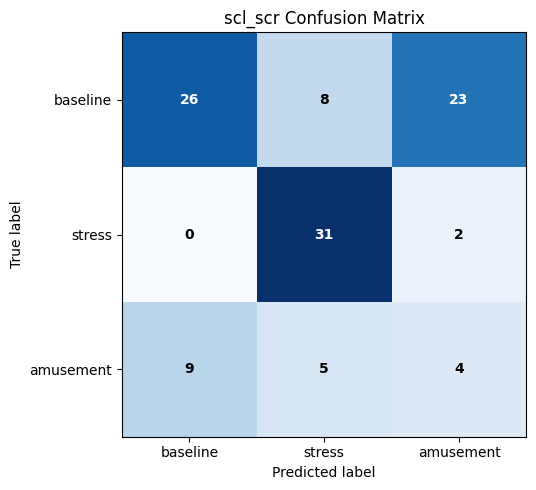

In [24]:
# [검증] scl_scr 체크포인트 단독 재평가 (Classification Report + 클래스별 정확도 + Confusion Matrix)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

SCL_SCR_MODEL_PATH = '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_scl_scr_model.pt'

if not os.path.exists(SCL_SCR_MODEL_PATH):
    raise FileNotFoundError(f'모델 파일이 없습니다: {SCL_SCR_MODEL_PATH}')

ckpt = torch.load(SCL_SCR_MODEL_PATH, map_location=device)
expected_n_features = int(ckpt.get('n_features', 10))
test_loader = get_test_loader(expected_n_features, batch_size=64)

model, display_name = build_model_from_checkpoint(ckpt, SCL_SCR_MODEL_PATH)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        outputs = model(sequences)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
acc = 100.0 * (all_preds == all_labels).mean()

print('=' * 60)
print(f'scl_scr checkpoint: {os.path.basename(SCL_SCR_MODEL_PATH)}')
print(f'Test Accuracy: {acc:.2f} %')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['baseline', 'stress', 'amusement'], digits=4, zero_division=0))

print('\n' + '=' * 60)
print('각 상태별 정확도')
print('=' * 60)
class_names = ['Baseline', 'Stress', 'Amusement']
for class_idx, class_name in enumerate(class_names):
    class_mask = (all_labels == class_idx)
    class_total = int(class_mask.sum())
    class_correct = int(((all_labels == class_idx) & (all_preds == class_idx)).sum())
    class_acc = (100.0 * class_correct / class_total) if class_total > 0 else 0.0
    print(f'{class_name}: {class_acc:.2f}% ({class_correct}/{class_total})')
print('=' * 60)

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('scl_scr Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['baseline', 'stress', 'amusement'])
ax.set_yticklabels(['baseline', 'stress', 'amusement'])
thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='white' if cm[i, j] > thresh else 'black', fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# 추가 모델 경로 등록 (중복 방지)
extra_model_path = '/home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_scl_scr_model.pt'

if 'MODEL_PATHS' not in globals():
    raise RuntimeError('먼저 2번 셀(체크포인트 비교 셀)을 실행하세요.')

if extra_model_path not in MODEL_PATHS:
    MODEL_PATHS.append(extra_model_path)
    print('✅ 추가 완료:', extra_model_path)
else:
    print('ℹ️ 이미 포함된 경로입니다:', extra_model_path)

print('\n현재 비교 대상 모델 목록:')
for i, p in enumerate(MODEL_PATHS, 1):
    print(f'{i}. {p}')

if not os.path.exists(extra_model_path):
    print('\n[WARN] 추가한 모델 파일이 현재 경로에 없습니다. 경로를 확인하세요.')
else:
    print('\n파일 존재 확인 완료.')

✅ 추가 완료: /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_scl_scr_model.pt

현재 비교 대상 모델 목록:
1. /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_more_epochs_model.pt
2. /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/GRU/gru_model.pt
3. /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/LSTM/lstm_model.pt
4. /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/Transformer/transformer_model.pt
5. /home/binghin2/Myproject/Research/WESAD_classification/Training/Save_model/CNN_Transformer/cnn_transformer_scl_scr_model.pt

파일 존재 확인 완료.


In [25]:
# 모델별 클래스별 F1/Recall 상세 비교 (특히 Amusement 확인)
from sklearn.metrics import confusion_matrix, f1_score

CLASS_ORDER = [0, 1, 2]
CLASS_NAMES = ['baseline', 'stress', 'amusement']

def evaluate_model_with_details(model, loader, dev):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(dev)
            labels = labels.to(dev)

            outputs = model(sequences)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            bs = labels.size(0)

            total_loss += loss.item() * bs
            total_samples += bs

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    avg_loss = total_loss / max(total_samples, 1)
    acc = 100.0 * (all_preds == all_labels).mean()
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    cm = confusion_matrix(all_labels, all_preds, labels=CLASS_ORDER)
    recalls = np.divide(np.diag(cm), cm.sum(axis=1), out=np.zeros(len(CLASS_ORDER), dtype=float), where=cm.sum(axis=1) != 0)
    per_class_f1 = f1_score(all_labels, all_preds, labels=CLASS_ORDER, average=None, zero_division=0)

    return {
        'loss': avg_loss,
        'acc': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'cm': cm,
        'recalls': recalls,
        'f1_each': per_class_f1,
    }

detailed_results = []
cm_results = []

for model_path in MODEL_PATHS:
    if not os.path.exists(model_path):
        print(f'[WARN] Missing model file: {model_path}')
        continue

    ckpt = torch.load(model_path, map_location=device)
    expected_n_features = int(ckpt.get('n_features', 10))
    test_loader = get_test_loader(expected_n_features, batch_size=64)

    model, display_name = build_model_from_checkpoint(ckpt, model_path)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device)

    r = evaluate_model_with_details(model, test_loader, device)

    detailed_results.append({
        'Model': display_name,
        'Checkpoint': os.path.basename(model_path),
        'n_features': expected_n_features,
        'Test Loss': r['loss'],
        'Test Accuracy (%)': r['acc'],
        'Macro F1': r['macro_f1'],
        'Weighted F1': r['weighted_f1'],
        'Baseline Recall': r['recalls'][0],
        'Stress Recall': r['recalls'][1],
        'Amusement Recall': r['recalls'][2],
        'Baseline F1': r['f1_each'][0],
        'Stress F1': r['f1_each'][1],
        'Amusement F1': r['f1_each'][2],
    })

    cm_results.append({
        'Model': display_name,
        'Checkpoint': os.path.basename(model_path),
        'cm': r['cm'],
    })

detailed_df = pd.DataFrame(detailed_results).sort_values(by=['Amusement Recall', 'Amusement F1', 'Macro F1'], ascending=False).reset_index(drop=True)
display_cols = [
    'Model', 'Checkpoint', 'n_features',
    'Test Accuracy (%)', 'Macro F1', 'Weighted F1',
    'Baseline Recall', 'Stress Recall', 'Amusement Recall',
    'Baseline F1', 'Stress F1', 'Amusement F1',
    'Test Loss',
]

print('\n' + '=' * 130)
print('모델별 클래스별 F1/Recall 비교 (Amusement 우선 정렬)')
print('=' * 130)
display(detailed_df[display_cols])
print('=' * 130)

/tmp/ipykernel_2009/3599547968.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


Processed TEST user: S15, n_features=9, windows=36
Processed TEST user: S16, n_features=9, windows=36
Processed TEST user: S17, n_features=9, windows=36


/tmp/ipykernel_2009/3599547968.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)
/tmp/ipykernel_2009/3599547968.py:62: 


모델별 클래스별 F1/Recall 비교 (Amusement 우선 정렬)


,Model,Checkpoint,n_features,Test Accuracy (%),Macro F1,Weighted F1,Baseline Recall,Stress Recall,Amusement Recall,Baseline F1,Stress F1,Amusement F1,Test Loss
0,GRU,gru_model.pt,10,60.185185,0.566446,0.609994,0.473684,0.939394,0.388889,0.586957,0.826667,0.285714,0.891524
1,Transformer,transformer_model.pt,10,48.148148,0.471786,0.497058,0.333333,0.818182,0.333333,0.422222,0.782609,0.210526,1.005524
2,1D-CNN+Transformer,cnn_transformer_more_epochs_model.pt,9,46.296296,0.412251,0.490469,0.596491,0.333333,0.277778,0.618182,0.440000,0.178571,1.270942
3,LSTM,lstm_model.pt,10,67.592593,0.593863,0.669007,0.666667,0.939394,0.222222,0.703704,0.849315,0.228571,0.795789
4,1D-CNN+Transformer,cnn_transformer_scl_scr_model.pt,10,56.481481,0.513542,0.572710,0.456140,0.939394,0.222222,0.565217,0.805195,0.170213,0.763116


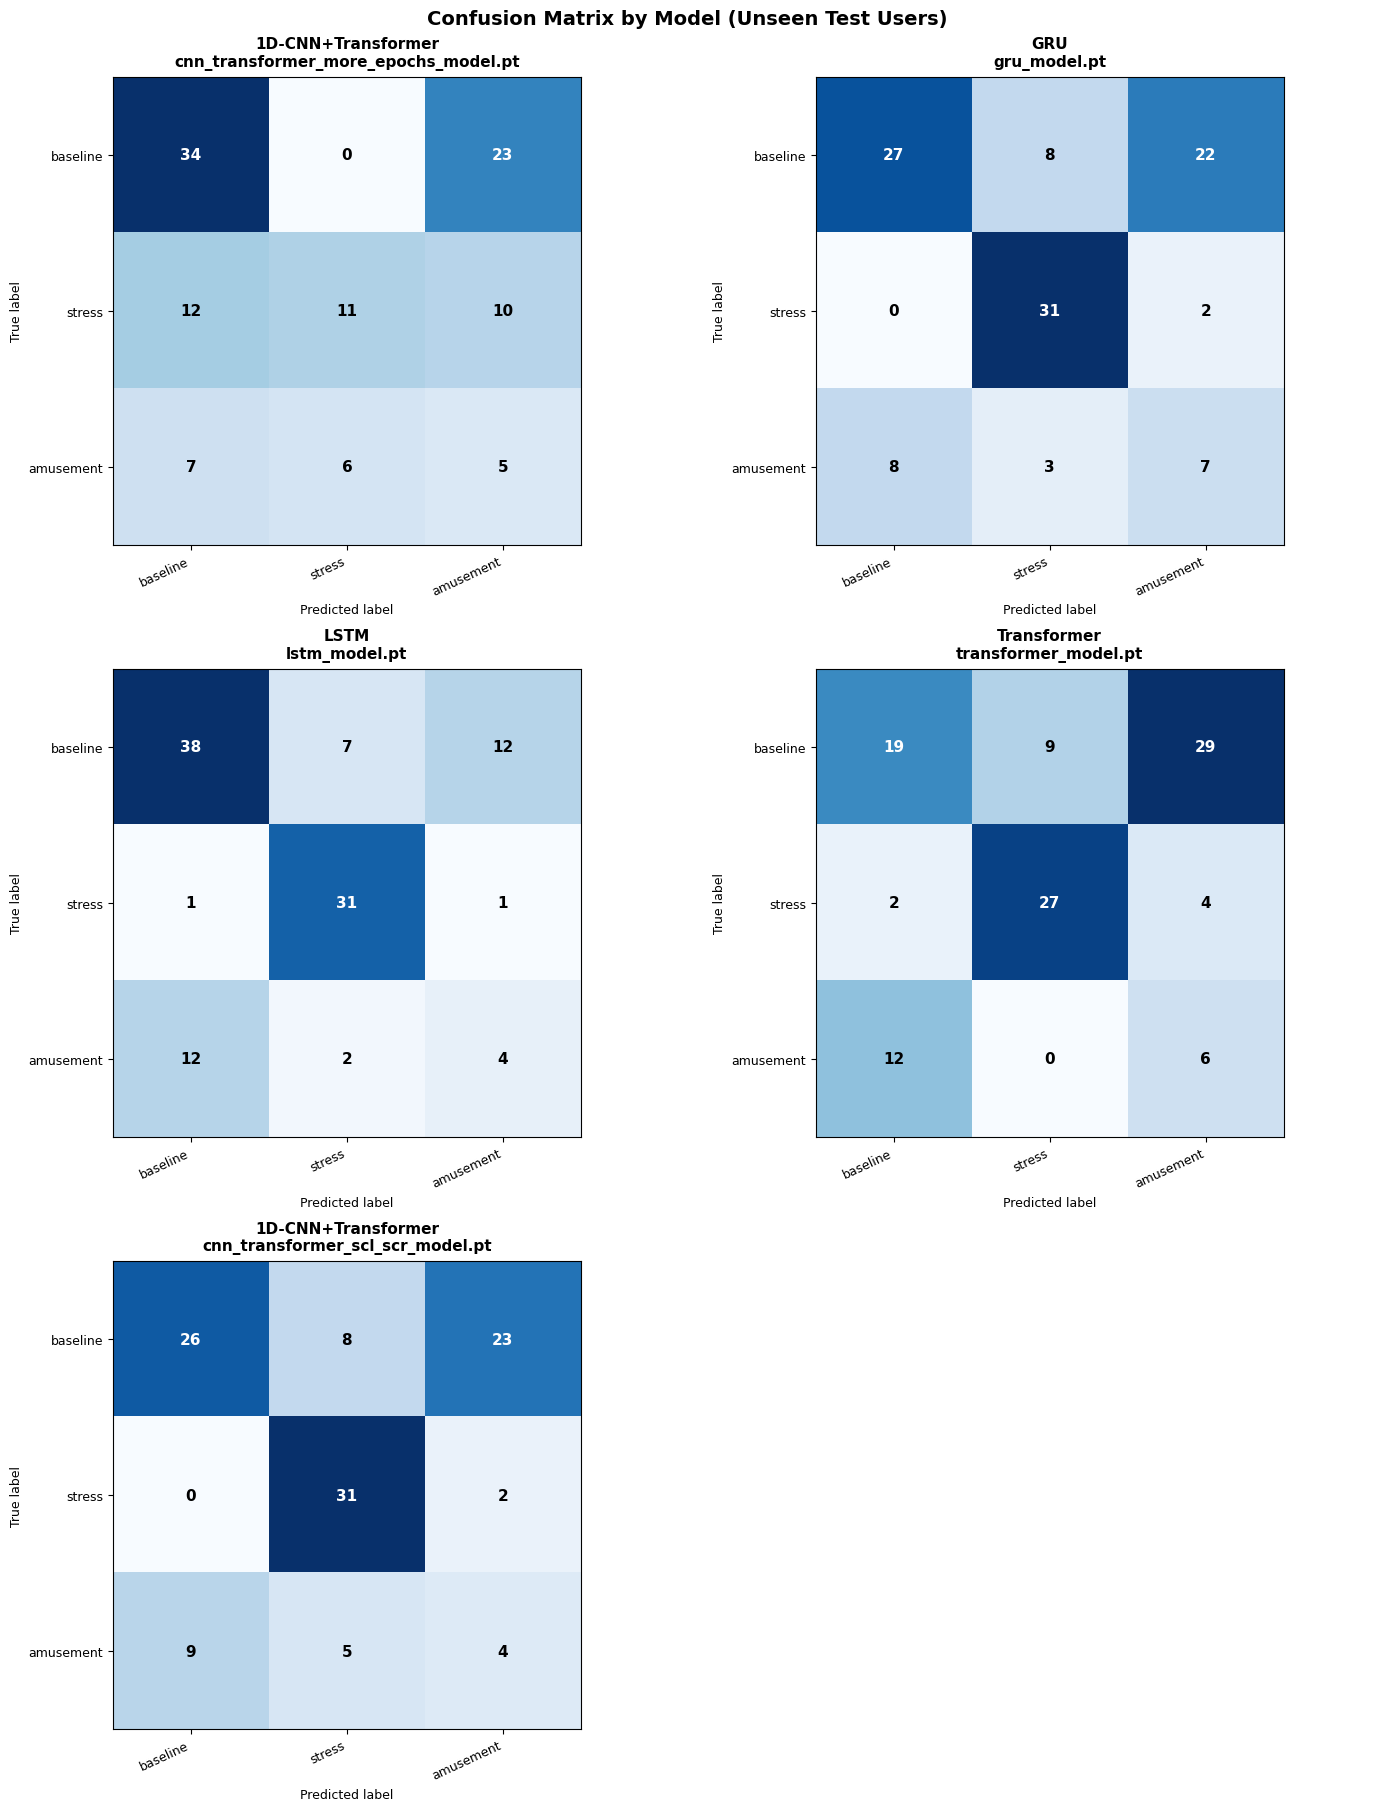

In [26]:
# Confusion Matrix 4개 자동 시각화 (모델별 오분류 패턴 비교)
if 'cm_results' not in globals() or len(cm_results) == 0:
    raise RuntimeError('먼저 이전 셀(클래스별 F1/Recall 비교 셀)을 실행하세요.')

n_models = len(cm_results)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows), constrained_layout=True)
if isinstance(axes, np.ndarray):
    axes = axes.reshape(-1)
else:
    axes = np.array([axes])

for idx, item in enumerate(cm_results):
    ax = axes[idx]
    cm = item['cm']
    model_name = item['Model']

    # 패널별로 독립적으로 렌더링 (공용 colorbar 제거)
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{model_name}\n{item["Checkpoint"]}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted label', fontsize=9)
    ax.set_ylabel('True label', fontsize=9)
    ax.set_xticks(np.arange(len(CLASS_NAMES)))
    ax.set_yticks(np.arange(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f'{cm[i, j]}',
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=11, fontweight='bold'
            )

# 남는 subplot 숨기기
for k in range(n_models, len(axes)):
    axes[k].axis('off')

fig.suptitle('Confusion Matrix by Model (Unseen Test Users)', fontsize=14, fontweight='bold')
plt.show()

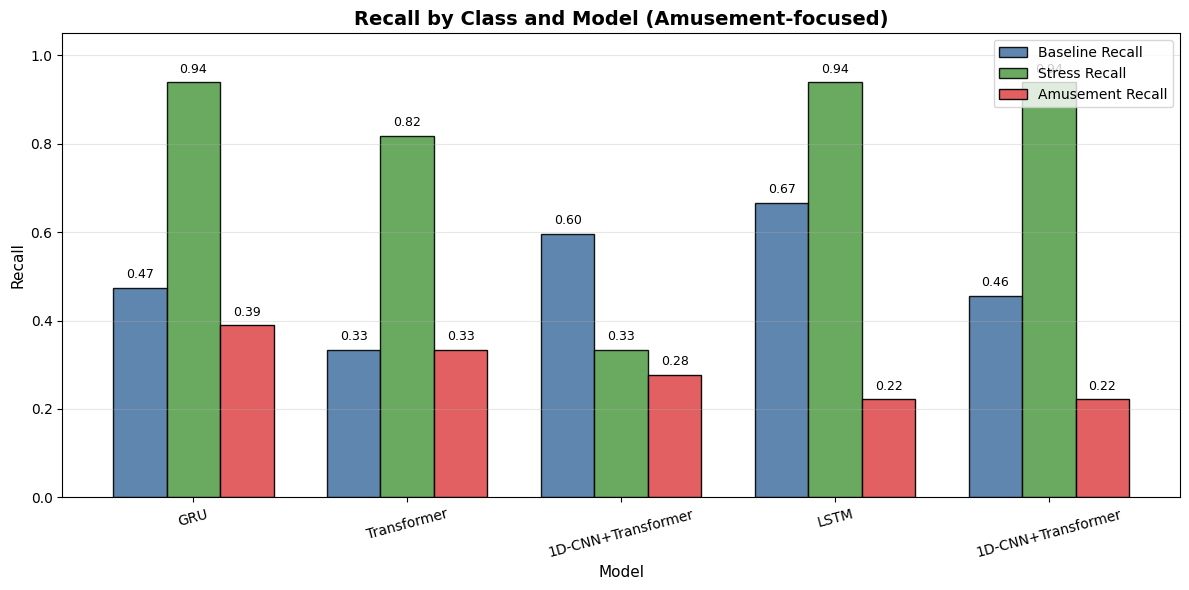


Amusement Recall ranking (high → low)


,Model,Amusement Recall,Amusement F1,Macro F1,Test Accuracy (%)
0,GRU,0.388889,0.285714,0.566446,60.185185
1,Transformer,0.333333,0.210526,0.471786,48.148148
2,1D-CNN+Transformer,0.277778,0.178571,0.412251,46.296296
3,LSTM,0.222222,0.228571,0.593863,67.592593
4,1D-CNN+Transformer,0.222222,0.170213,0.513542,56.481481


In [27]:
# 클래스별 Recall 비교 플롯 (Baseline / Stress / Amusement)
if 'detailed_df' not in globals() or detailed_df.empty:
    raise RuntimeError('먼저 클래스별 F1/Recall 비교 셀을 실행하세요.')

plot_df = detailed_df.copy()
plot_df = plot_df.sort_values(by='Amusement Recall', ascending=False).reset_index(drop=True)

models = plot_df['Model'].tolist()
x = np.arange(len(models))
w = 0.25

baseline_r = plot_df['Baseline Recall'].values
stress_r = plot_df['Stress Recall'].values
amusement_r = plot_df['Amusement Recall'].values

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w, baseline_r, width=w, label='Baseline Recall', color='#4e79a7', edgecolor='black', alpha=0.9)
b2 = ax.bar(x, stress_r, width=w, label='Stress Recall', color='#59a14f', edgecolor='black', alpha=0.9)
b3 = ax.bar(x + w, amusement_r, width=w, label='Amusement Recall', color='#e15759', edgecolor='black', alpha=0.95)

ax.set_title('Recall by Class and Model (Amusement-focused)', fontsize=14, fontweight='bold')
ax.set_ylabel('Recall', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f'{h:.2f}',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

print('\nAmusement Recall ranking (high → low)')
display(plot_df[['Model', 'Amusement Recall', 'Amusement F1', 'Macro F1', 'Test Accuracy (%)']])